Dataset: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load dataset
data = pd.read_csv("train.csv")
print("Shape:", data.shape)

print(data.head())
print("="*100)
print(data.columns)

Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

image.png

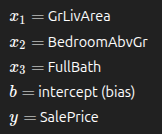

In [ ]:
print("Original Shape:", data.shape)
data = data.head(50)

print("New Shape:", data.shape)
print(data.head())

Original Shape: (1460, 81)
New Shape: (50, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  S

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])

print("Numeric Columns:")
print(numeric_data.columns)
print(numeric_data.shape)

Numeric Columns:
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')
(50, 38)


In [ ]:
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]
target = "SalePrice"

X = data[features].values
y = data[target].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print(X[:10])
print(y[:10])

Shape of X: (50, 3)
Shape of y: (50,)
[[1710    3    2]
 [1262    3    2]
 [1786    3    2]
 [1717    3    1]
 [2198    4    2]
 [1362    1    1]
 [1694    3    2]
 [2090    3    2]
 [1774    2    2]
 [1077    2    1]]
[208500 181500 223500 140000 250000 143000 307000 200000 129900 118000]


# Adding Bias Column

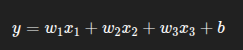


## Matrix form
y = Xθ

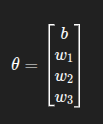

After adding 1, X becomes

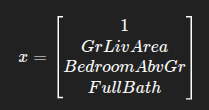

In [ ]:
m = X.shape[0]

ones = np.ones((m,1))
X = np.hstack((ones, X))   # shape (m,4)

print(X[:10])


[[1.000e+00 1.710e+03 3.000e+00 2.000e+00]
 [1.000e+00 1.262e+03 3.000e+00 2.000e+00]
 [1.000e+00 1.786e+03 3.000e+00 2.000e+00]
 [1.000e+00 1.717e+03 3.000e+00 1.000e+00]
 [1.000e+00 2.198e+03 4.000e+00 2.000e+00]
 [1.000e+00 1.362e+03 1.000e+00 1.000e+00]
 [1.000e+00 1.694e+03 3.000e+00 2.000e+00]
 [1.000e+00 2.090e+03 3.000e+00 2.000e+00]
 [1.000e+00 1.774e+03 2.000e+00 2.000e+00]
 [1.000e+00 1.077e+03 2.000e+00 1.000e+00]]


# Our main goal is to minimize the error
Error is difference between actual price y, and predicted price Xθ

E = y - Xθ

The Cost Function is Sum of Squrad errors

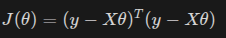

## In calculus to find the minimum of any curve, we take the derivative and set it to zero,

If we take the derivative of J(θ) with respect to θ and set it to 0,

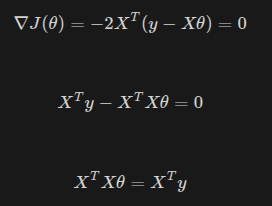

To isolate θ, we multiply both sides by the inverse of XTX



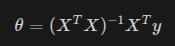

In [ ]:
# X^T flips rows and columns
X_T = X.T

print("Shape of X^T:", X_T.shape)

Shape of X^T: (4, 50)


# Multiply X^T X


As (4, 50) (50, 4) yeilds (4, 4) which is Covariance Matrix. It summarizes how all the features relate to each other across the dataset.

In [ ]:
# This creates a square matrix
XTX = np.dot(X_T, X)

print("Shape of X^T X:", XTX.shape)
print("Number of houses used:", X.shape[0])
print("Number of parameters learned:", X.shape[1])

Shape of X^T X: (4, 4)
Number of houses used: 50
Number of parameters learned: 4


# Take Inverse

In [ ]:
# This solves system of equations
XTX_inv = np.linalg.inv(XTX)
print(XTX_inv)

[[ 3.72817943e-01 -1.10647615e-04 -7.94810293e-02  1.21665609e-02]
 [-1.10647615e-04  2.34341670e-07 -2.01501880e-05 -1.10889413e-04]
 [-7.94810293e-02 -2.01501880e-05  4.59910146e-02 -1.07999508e-02]
 [ 1.21665609e-02 -1.10889413e-04 -1.07999508e-02  1.15869495e-01]]


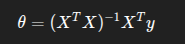

# Multiply X^T y


In [ ]:
XTy = np.dot(X_T, y)
print(XTy)

[8.98188600e+06 1.38719722e+10 2.52042860e+07 1.49846860e+07]


# Final Theta


In [ ]:
theta = np.dot(XTX_inv, XTy)

print("Theta values:")
print(theta)

Theta values:
[-7242.8764485     87.4427321   3924.42078949 35086.76266548]


# Interpretation of Theta

theta = bias


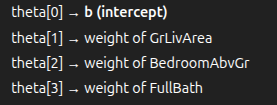

In [ ]:
b = theta[0]
w1 = theta[1]
w2 = theta[2]
w3 = theta[3]

print("b =", b)
print("w1 =", w1)
print("w2 =", w2)
print("w3 =", w3)

b = -7242.876448497875
w1 = 87.44273210098754
w2 = 3924.4207894899882
w3 = 35086.76266548448


# Manual Prediction
![image.png](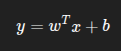
)

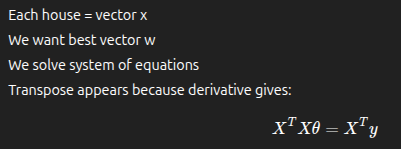

In [ ]:
print("\nFinal Equation:")
print(f"SalePrice = {w1:.2f}*GrLivArea + "
      f"{w2:.2f}*BedroomAbvGr + "
      f"{w3:.2f}*FullBath + "
      f"{b:.2f}")


Final Equation:
SalePrice = 87.44*GrLivArea + 3924.42*BedroomAbvGr + 35086.76*FullBath + -7242.88


In [ ]:
# Predictions
y_pred = np.dot(X, theta)

In [ ]:
new_houses = np.array([
    [800, 3, 2],
    [2500, 4, 5],
    [1500, 3, 2],
    [2000, 4, 3],
    [1200, 2, 1]
])

# Add bias column
ones_new = np.ones((new_houses.shape[0],1))
new_houses_bias = np.hstack((ones_new, new_houses))

new_predictions = np.dot(new_houses_bias, theta)

for i in range(len(new_houses)):
    print(f"House {i+1} → Predicted Price = {new_predictions[i]:.2f}")

House 1 → Predicted Price = 144658.10
House 2 → Predicted Price = 402495.45
House 3 → Predicted Price = 205868.01
House 4 → Predicted Price = 288600.56
House 5 → Predicted Price = 140624.01


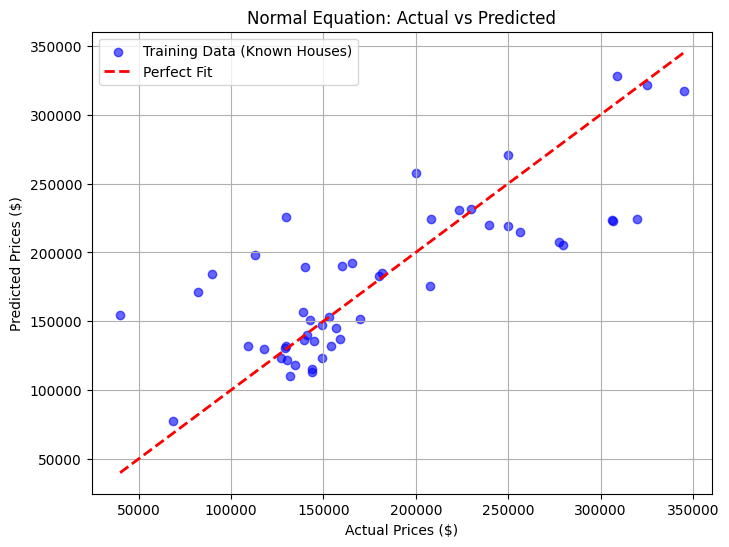

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot the training data (Actual vs Predicted)
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color="blue", label="Training Data (Known Houses)", alpha=0.6)

# 2. Plot the "Perfect Prediction" line
# If the model was 100% perfect, every blue dot would fall exactly on this red line.
min_price = y.min()
max_price = y.max()
plt.plot([min_price, max_price], [min_price, max_price],
         color="red", linewidth=2, linestyle="--", label="Perfect Fit")

plt.xlabel("Actual Prices ($)")
plt.ylabel("Predicted Prices ($)")
plt.title("Normal Equation: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

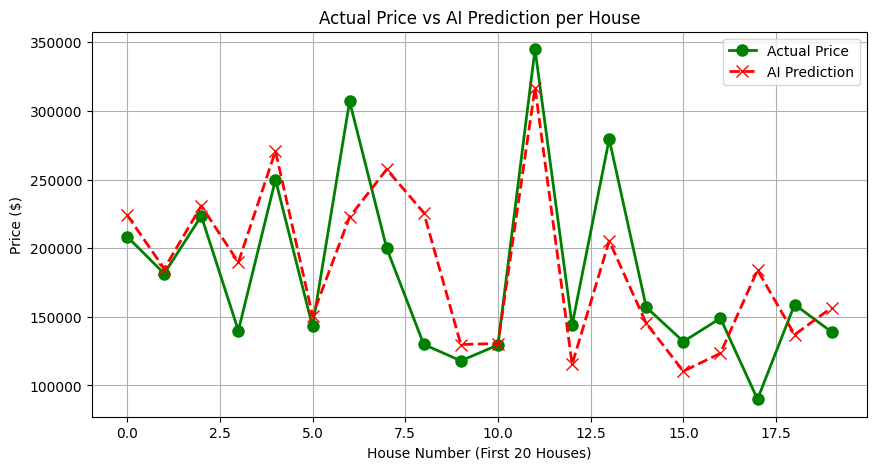

In [ ]:
import matplotlib.pyplot as plt

# Let's just look at the first 20 houses so it's not too crowded
num_houses_to_show = 20

plt.figure(figsize=(10, 5))

# Plot actual prices as Green dots
plt.plot(y[:num_houses_to_show], 'go-', label="Actual Price", linewidth=2, markersize=8)

# Plot predicted prices as Red X's
plt.plot(y_pred[:num_houses_to_show], 'rx--', label="AI Prediction", linewidth=2, markersize=8)

plt.xlabel("House Number (First 20 Houses)")
plt.ylabel("Price ($)")
plt.title("Actual Price vs AI Prediction per House")
plt.legend()
plt.grid(True)
plt.show()

# Linear Regression using Gradient Descent

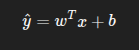

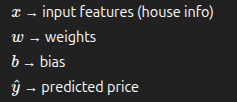

# For multiple houses

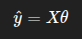

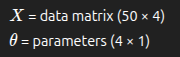

# We dont know the optimal value for θ

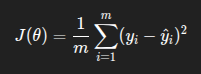


Makes Error Positive

Penalizes large mistakes more

Smooth function (Easy to differentiate)

# We substitute y = Xθ

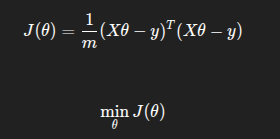

Instead of solving derivative = 0 directly (Normal Equation),
we move step-by-step toward minimum.



# Why not solve it Directly?

The eqn,

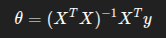

The problem is

If we have 100000 features, (X^T)X is 100k X 100k

Inversion cost is O(n^3) which is extremely expensive

Sometimes it is not even invertible

# Derivative of MSE (Gradient)
It tells us which direction should θ move to reduce error

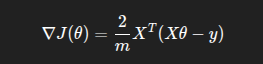

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
data = pd.read_csv("train.csv")

print("Original Shape:", data.shape)

print(data.head())
print("="*100)
print(data.columns)

Original Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePr

In [ ]:
print("Original Shape:", data.shape)

data = data.head(50)

print("New Shape:", data.shape)
print(data.head())

Original Shape: (1460, 81)
New Shape: (50, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  S

# Viewing the numeric columns only

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])

print("Numeric Columns:")
print(numeric_data.columns)
print(numeric_data.shape)

Numeric Columns:
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')
(50, 38)


# Select Features & Target
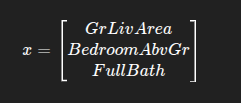

In [ ]:
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]
target = "SalePrice"

X = data[features].values
y = data[target].values

# Save original before scaling
X_original = X.copy()

# Scale features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

# Scaling in GD is necessary because the gradient will catch up the Area feature and it will be hard to reach the minimum.

By subtracting the mean and dividing by the standard deviation, we force all features to have a mean of 0 and variance of 1

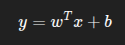

# Instead of keeping b separate, we convert y and then θ is,

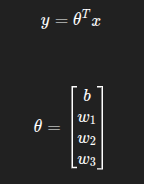

In [ ]:
# Adding column of 1s to include intercept (b)
ones = np.ones((X.shape[0], 1))
X = np.hstack((ones, X))

print("Shape after adding bias:", X.shape)
print(X[:5])

Shape after adding bias: (50, 4)
[[ 1.          0.68615437  0.41208169  0.82199494]
 [ 1.         -0.35277073  0.41208169  0.82199494]
 [ 1.          0.86240059  0.41208169  0.82199494]
 [ 1.          0.70238757  0.41208169 -0.82199494]
 [ 1.          1.81784063  1.78568733  0.82199494]]


# After adding bias, each row becomes
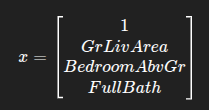

In [ ]:
m = X.shape[0]   # number of houses
n = X.shape[1]  # number of parameters

# or m, n = X

print("m:", m)
print("n:", n)


theta = np.zeros(n)
alpha = 0.0000001
iterations = 10000
loss_history = []

m: 50
n: 4


![Alt](https://towardsdatascience.com/wp-content/uploads/2020/11/1DHootdFfDVov_7BDt35-gA.jpg)

# Why θ = 0?
θ = [0,0,0,0]

we start with no knowledge

Gredient Descent will move those vals

# Alpha is the learning rate which controls step size

If alpha = too big, explodes

Too small = takes more time to learn

# Iterations means how many steps it will take

# loss_history = [] stores error over time for plotting

# What is happenning at the Gradient?
Error E = (Xθ - y)
Cost func Matrix is,

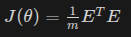

# Taking the derivative with respect to θ

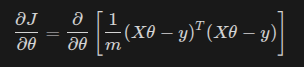

# After applying calculus,

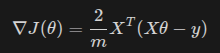

XT is cross correlation. Multiplying features XT by the error

In [ ]:
for i in range(iterations):
    # Step 1: Prediction
    y_pred = np.dot(X, theta)

    # Step 2: Error
    error = y_pred - y

    # Step 3: Compute gradient
    gradient = (2/m) * np.dot(X.T, error) # Dimension is 4, 1)

    # Step 4: Update parameters
    theta = theta - alpha * gradient

    # Step 5: Compute loss
    loss = np.mean(error**2)
    loss_history.append(loss)

    # --- UPDATED PRINT BLOCK ---
    if i % 1000 == 0:
        # theta[0] is the Bias, the rest are the Weights for the features
        bias = theta[0]
        weights = theta[1:]

        print(f"Iteration {i:5d} | Loss: {loss:.2f}")
        print(f"  -> Bias (b)   : {bias:.4f}")
        print(f"  -> Weights (w): {np.round(weights, 4)}")
        print("-" * 60)

Iteration     0 | Loss: 37437588471.92
  -> Bias (b)   : 0.0359
  -> Weights (w): [0.0109 0.0052 0.0099]
------------------------------------------------------------
Iteration  1000 | Loss: 37422242524.50
  -> Bias (b)   : 35.9599
  -> Weights (w): [10.8666  5.2411  9.9499]
------------------------------------------------------------
Iteration  2000 | Loss: 37406903680.33
  -> Bias (b)   : 71.8766
  -> Weights (w): [21.7183 10.4744 19.8858]
------------------------------------------------------------
Iteration  3000 | Loss: 37391571935.78
  -> Bias (b)   : 107.7862
  -> Weights (w): [32.566  15.7049 29.8178]
------------------------------------------------------------
Iteration  4000 | Loss: 37376247287.24
  -> Bias (b)   : 143.6886
  -> Weights (w): [43.4097 20.9328 39.7459]
------------------------------------------------------------
Iteration  5000 | Loss: 37360929731.06
  -> Bias (b)   : 179.5838
  -> Weights (w): [54.2493 26.158  49.67  ]
------------------------------------------

In [ ]:
print("\n" + "="*65)
print("FINAL RESULTS: WHAT THE MACHINE LEARNED (THE 'THETA' VECTOR)")
print("="*65)

# Initial state (from Page 8, theta was initialized as np.zeros(n))
print("1. STARTING MATRIX (Theta at t=0):")
print("[ 0.0000,  0.0000,  0.0000,  0.0000 ]")

# Final state
print("2. FINAL MATRIX (Theta at t=10000):")
print(f"   [{theta[0]:.4f}, {theta[1]:.4f}, {theta[2]:.4f}, {theta[3]:.4f}]")

print("3. TRANSLATION OF THE FILTER COEFFICIENTS:")
# Since the features were Z-Score Scaled, the weights represent the
# price change per 1 Standard Deviation increase.
print(f"   Bias (b)     : ${theta[0]:,.2f}")
print(f"   Bed Weight   : ${theta[2]:,.2f}")
print(f"   Area Weight  : ${theta[1]:,.2f}Area)")
print(f"   Bath Weight  : ${theta[3]:,.2f} (Added value per +1 Std.Dev of Bathrooms)")
print("="*65)


FINAL RESULTS: WHAT THE MACHINE LEARNED (THE 'THETA' VECTOR)
1. STARTING MATRIX (Theta at t=0):
[ 0.0000,  0.0000,  0.0000,  0.0000 ]
2. FINAL MATRIX (Theta at t=10000):
   [358.9164, 108.3764, 52.2386, 99.2213]
3. TRANSLATION OF THE FILTER COEFFICIENTS:
   Bias (b)     : $358.92
   Bed Weight   : $52.24
   Area Weight  : $108.38Area)
   Bath Weight  : $99.22 (Added value per +1 Std.Dev of Bathrooms)


# What Is Happening Each Iteration?

Model predicts prices

Compares with actual prices

Measures error

Calculates slope of loss surface

Moves slightly downhill

Repeats

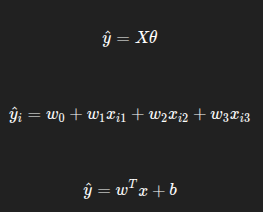

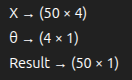

# Error calculation

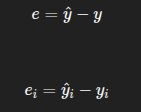

# Gradient Calculation

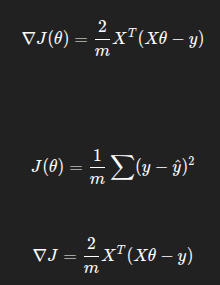

Gradient tells us how much each parameter is responsible for the total error

# Theta Calculation
theta = theta - alpha * gradient

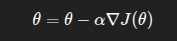

# We subtract because,
Gradient points uphill but,

we need to move downhill.

This is steepest descent method.

# Now we compute current error to see if learning improves

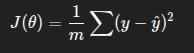

Our main task is to minimize J(θ)

# At each iteration we,

Compute Slope

Move downhill

Reduce Error

Repeat

# Manual solving means:

Derive equations

Solve large linear systems

Invert giant matrices

A dataset with 10M example,

Matrix inverse is impossible.

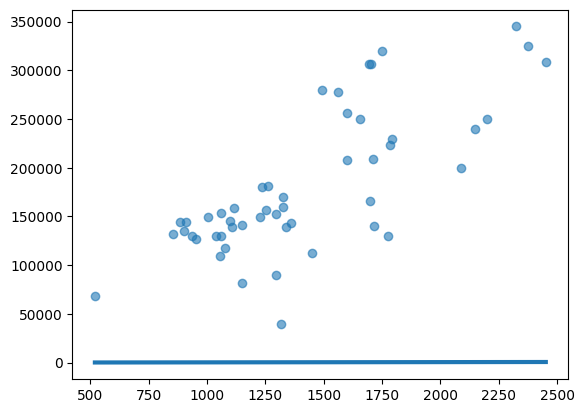

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_original[:,0], y, alpha=0.6, label='Actual')

gr_range_original = np.linspace(
    X_original[:,0].min(),
    X_original[:,0].max(),
    100
)

# Scale the range before prediction
gr_range_scaled = (gr_range_original - X_mean[0]) / X_std[0]

X_line = np.column_stack((
    np.ones(100),
    gr_range_scaled,
    np.full(100, 0),  # bedroom mean (scaled = 0)
    np.full(100, 0)   # bath mean (scaled = 0)
))

y_line = np.dot(X_line, theta)

plt.plot(gr_range_original, y_line, linewidth=3, label='Best Fit Line')

In [ ]:
# New houses (GrLivArea, BedroomAbvGr, FullBath)
new_houses = np.array([
    [800, 3, 2],
    [2500, 4, 5],
    [1500, 3, 2],
    [2000, 4, 3],
    [1200, 2, 1]
])

X_mean = X_original.mean(axis=0)
X_std = X_original.std(axis=0)

new_houses_scaled = (new_houses - X_mean) / X_std

# Add bias column
ones_new = np.ones((new_houses_scaled.shape[0], 1))
new_houses_scaled = np.hstack((ones_new, new_houses_scaled))

new_predictions = np.dot(new_houses_scaled, theta)

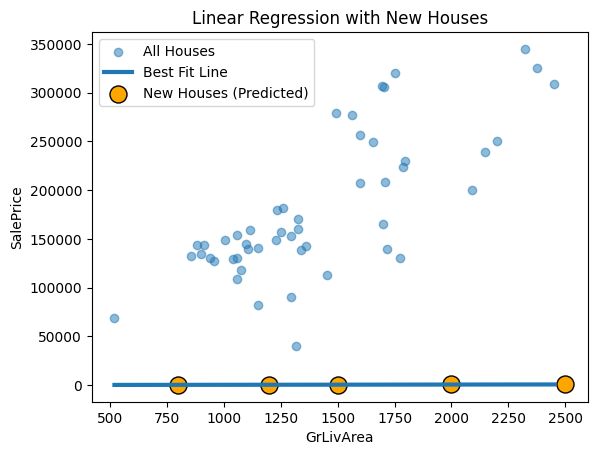

In [ ]:
# Use original (unscaled) GrLivArea for clean X-axis
gr_original = X_original[:, 0]

# Create smooth range in ORIGINAL scale
gr_range_original = np.linspace(gr_original.min(), gr_original.max(), 100)

# Convert to scaled (because model trained on scaled data)
gr_range_scaled = (gr_range_original - X_mean[0]) / X_std[0]

# Keep other features at mean (which is 0 after scaling)
X_line = np.column_stack((
    np.ones(100),
    gr_range_scaled,
    np.zeros(100),  # BedroomAbvGr mean (scaled = 0)
    np.zeros(100)   # FullBath mean (scaled = 0)
))

y_line = np.dot(X_line, theta)

# Plot actual data (ORIGINAL X axis)
plt.scatter(gr_original, y, alpha=0.5, label='All Houses')

# Plot straight regression line
plt.plot(gr_range_original, y_line, linewidth=3, label='Best Fit Line')

# Plot new houses (convert back to original scale for X-axis)
plt.scatter(new_houses[:, 0], new_predictions,
            color='orange', s=150, edgecolor='black',
            label='New Houses (Predicted)')

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Linear Regression with New Houses")
plt.legend()
plt.show()

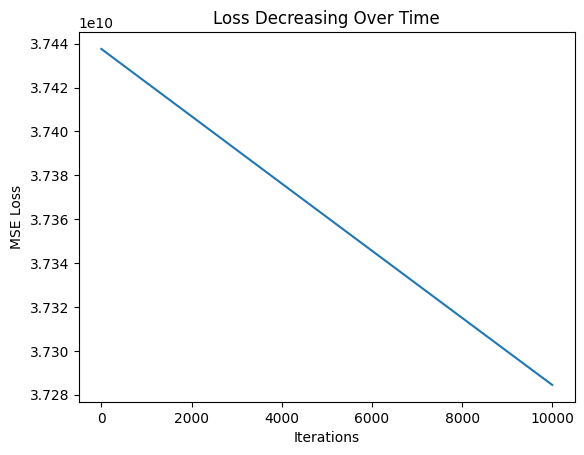

In [ ]:
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Loss Decreasing Over Time")
plt.show()

In [ ]:
for i in range(len(new_houses)):
    print(f"House {i+1}: Features={new_houses[i]}, Predicted Price={new_predictions[i]:.2f}")

House 1: Features=[800   3   2], Predicted Price=307.66
House 2: Features=[2500    4    5], Predicted Price=1296.03
House 3: Features=[1500    3    2], Predicted Price=483.59
House 4: Features=[2000    4    3], Predicted Price=844.12
House 5: Features=[1200    2    1], Predicted Price=173.31


# Using LinearRegression
Singular Value Decomposition (SVD)

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Create Data

In [ ]:
# Load dataset
data = pd.read_csv("train.csv")
print("Shape:", data.shape)

print(data.head())
print("="*100)
print(data.columns)

Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

In [ ]:
print("Original Shape:", data.shape)
data = data.head(50)

print("New Shape:", data.shape)
print(data.head())

Original Shape: (1460, 81)
New Shape: (50, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  S

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])

print("Numeric Columns:")
print(numeric_data.columns)
print(numeric_data.shape)

Numeric Columns:
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')
(50, 38)


In [ ]:
features = ["GrLivArea", "BedroomAbvGr", "FullBath"]
target = "SalePrice"

X = data[features].values
y = data[target].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print(X[:10])
print(y[:10])

Shape of X: (50, 3)
Shape of y: (50,)
[[1710    3    2]
 [1262    3    2]
 [1786    3    2]
 [1717    3    1]
 [2198    4    2]
 [1362    1    1]
 [1694    3    2]
 [2090    3    2]
 [1774    2    2]
 [1077    2    1]]
[208500 181500 223500 140000 250000 143000 307000 200000 129900 118000]


In [ ]:
# # Features (X)
# X = np.array([
#     # Rooms, Bathrooms, Sqft
#     [2, 1, 800],
#     [3, 2, 1200],
#     [4, 3, 2000],
#     [3, 2, 1500],
#     [5, 4, 2500]
# ])

# # Target (y) -> house prices
# y = np.array([150000, 250000, 450000, 300000, 600000])

In [ ]:
print(X[:10], y[:10])

[[1710    3    2]
 [1262    3    2]
 [1786    3    2]
 [1717    3    1]
 [2198    4    2]
 [1362    1    1]
 [1694    3    2]
 [2090    3    2]
 [1774    2    2]
 [1077    2    1]] [208500 181500 223500 140000 250000 143000 307000 200000 129900 118000]


In [ ]:
print(X.shape)
print(y.shape)

(50, 3)
(50,)


# Create an empty model structure, with no weights

In [ ]:
model = LinearRegression()

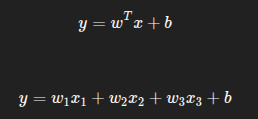

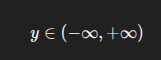

# Training

In [ ]:
model.fit(X, y)

LinearRegression()

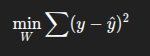

Find weights that minimizes error

No gradient descent

No activation function

In [ ]:
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [   87.4427321   3924.42078949 35086.76266548]
Bias: -7242.8764485970605


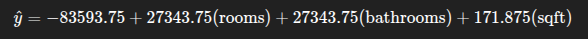

# Predict Price

In [ ]:
new_houses = np.array([
    [800, 3, 2],
    [2500, 4, 5],
    [1500, 3, 2],
    [2000, 4, 3],
    [1200, 2, 1]
])

predicted_price = model.predict(new_houses)
#y' = XW+b
print("Predicted Price:", predicted_price)

# Data → fit() → Solve matrix equation → Store weights → predict()

Predicted Price: [144658.09693169 402495.45028943 205868.00940243 288600.55890793
 140624.00631714]


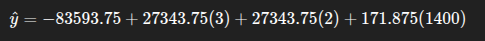

# Plotting

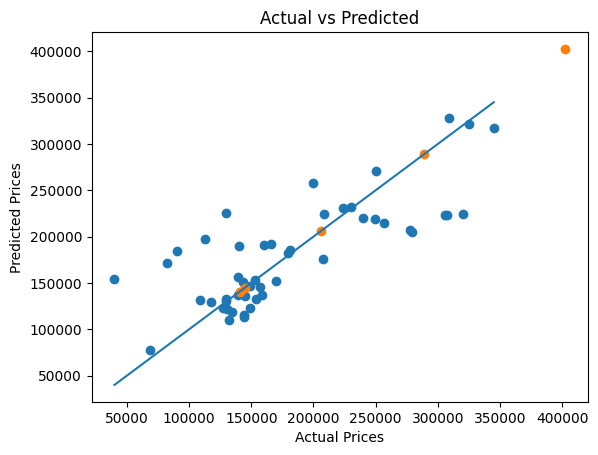

In [ ]:
import matplotlib.pyplot as plt

# Predictions for training data
y_pred = model.predict(X)

# Plot training predictions
plt.scatter(y, y_pred)

# Plot perfect line
plt.plot([y.min(), y.max()], [y.min(), y.max()])

new_pred = model.predict(new_houses)

plt.scatter(new_pred, new_pred, marker='o')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)


# Or
mse_manual = np.mean((y - y_pred)**2)
print("Manual MSE:", mse_manual)

MSE: 1985092377.7178144
Manual MSE: 1985092377.7178144
